# Simulador Playoffs Liga Argentina

## Preprocesamiento de datos

### En esta seccion, importamos las librerias y los datos y acomodamos caracteristicas

In [18]:
#importamos librerias
import numpy as np 
import pandas as pd 
from sklearn import svm 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV 
from sklearn.metrics import make_scorer, balanced_accuracy_score
from sklearn.pipeline import make_pipeline 
import xgboost 
from scipy import stats 
from fitter import Fitter 
import copy 
import matplotlib.pyplot as plt  
import seaborn as sns  

In [19]:
#Importamos los datos de la temporada 25/26 de la liga argentina
df = pd.read_csv("ligaArgentinaStatsSemis.csv",sep=";")
df=df.dropna()


In [20]:
#Reconvertimos las columnas de tiros para extraer los tiros convertidos y fallados
df[["HOME_2PTM","HOME_2PTA"]]=df["HOME_2PT"].str.split("/",expand=True).astype(float)
df[["HOME_3PTM","HOME_3PTA"]]=df["HOME_3PT"].str.split("/",expand=True).astype(float)
df[["HOME_FTM","HOME_FTA"]]=df["HOME_FT"].str.split("/",expand=True).astype(float)
df["DIF_RNK_HOME_AWAY"]=df["HOME_RNK"]-df["AWAY_RNK"]
df[["AWAY_2PTM","AWAY_2PTA"]]=df["AWAY_2PT"].str.split("/",expand=True).astype(float)
df[["AWAY_3PTM","AWAY_3PTA"]]=df["AWAY_3PT"].str.split("/",expand=True).astype(float)
df[["AWAY_FTM","AWAY_FTA"]]=df["AWAY_FT"].str.split("/",expand=True).astype(float)
df["DIF_RNK_AWAY_HOME"]=df["AWAY_RNK"]-df["HOME_RNK"]

In [21]:
df

,HOME_TEAM,AWAY_TEAM,HOME_PTS,HOME_2PT,HOME_2PT_PCT,HOME_3PT,HOME_3PT_PCT,HOME_FT,HOME_FT_PCT,HOME_DEF_REB,...,HOME_FTM,HOME_FTA,DIF_RNK_HOME_AWAY,AWAY_2PTM,AWAY_2PTA,AWAY_3PTM,AWAY_3PTA,AWAY_FTM,AWAY_FTA,DIF_RNK_AWAY_HOME
0,Huracan Las Heras,Hindu Cordoba,122,24/50,48,16/39,41,26/31,83,28,...,26.0,31.0,13,27.0,44.0,14.0,32.0,24.0,39.0,-13
1,Villa San Martin,Independiente Sde,74,21/46,45,6/21,28,14/17,82,21,...,14.0,17.0,23,21.0,45.0,2.0,13.0,11.0,13.0,-23
2,Colon,San Isidro,84,18/38,47,14/28,50,6/10,60,22,...,6.0,10.0,-21,23.0,36.0,10.0,30.0,15.0,21.0,21
3,Suardi,Bochas,90,16/38,42,12/22,54,22/32,68,31,...,22.0,32.0,11,26.0,44.0,10.0,31.0,10.0,21.0,-11
4,Union Mdp,Gimnasia La Plata,85,20/31,64,8/25,32,21/35,60,20,...,21.0,35.0,-26,22.0,34.0,13.0,29.0,13.0,21.0,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
623,Gimnasia La Plata,Barrio Parque,84,20/32,62,10/23,43,14/18,77,30,...,14.0,18.0,51,13.0,26.0,9.0,33.0,12.0,19.0,-51
624,Viedma,San Isidro,73,18/27,66,8/36,22,13/18,72,26,...,13.0,18.0,31,18.0,29.0,5.0,29.0,16.0,18.0,-31
625,Gimnasia La Plata,Barrio Parque,86,26/39,66,3/19,15,25/36,69,24,...,25.0,36.0,20,16.0,27.0,13.0,28.0,12.0,21.0,-20
626,La Union Colon,Santa Paula,82,22/43,51,9/28,32,11/20,55,25,...,11.0,20.0,17,16.0,34.0,11.0,25.0,14.0,18.0,-17


In [22]:
#convertimos los porcentajes a por 100
df["HOME_2PT_PCT"]=(df["HOME_2PTM"]/df["HOME_2PTA"])*100
df["HOME_3PT_PCT"]=(df["HOME_3PTM"]/df["HOME_3PTA"])*100
df["HOME_FT_PCT"]=(df["HOME_FTM"]/df["HOME_FTA"])*100
df["AWAY_2PT_PCT"]=(df["AWAY_2PTM"]/df["AWAY_2PTA"])*100
df["AWAY_3PT_PCT"]=(df["AWAY_3PTM"]/df["AWAY_3PTA"])*100
df["AWAY_FT_PCT"]=(df["AWAY_FTM"]/df["AWAY_FTA"])*100

In [23]:
#creamos una variable categorica para ver si gano de local el partido
df["HOME_WINS"]=(df["HOME_PTS"]>df["AWAY_PTS"]).astype(int)

In [24]:
#convertimos el dataset en numerico para que funcione nuestro modelo
dfNumerical=df[['HOME_TEAM',
 'AWAY_TEAM',
 'HOME_PTS',
 'HOME_2PTM',
 'HOME_2PTA',
 'HOME_2PT_PCT',
 'HOME_3PTM',
 'HOME_3PTA',                 
 'HOME_3PT_PCT',
 'HOME_FTM',
 'HOME_FTA',                  
 'HOME_FT_PCT',
 'HOME_DEF_REB',
 'HOME_OFF_REB',
 'HOME_TOT_REB',
 'HOME_AST',
 'HOME_STL',
 'HOME_TOV',
 'HOME_COM_BLK',
 'HOME_REC_BLK',
 'HOME_COM_PF',
 'HOME_REC_PF',
 'DIF_RNK_HOME_AWAY',
 'AWAY_PTS',
 'AWAY_2PTM',
 'AWAY_2PTA',
 'AWAY_2PT_PCT',
 'AWAY_3PTM',
 'AWAY_3PTA',
 'AWAY_3PT_PCT',
 'AWAY_FTM',
 'AWAY_FTA',
 'AWAY_FT_PCT',
 'AWAY_DEF_REB',
 'AWAY_OFF_REB',
 'AWAY_TOT_REB',
 'AWAY_AST',
 'AWAY_STL',
 'AWAY_TOV',
 'AWAY_COM_BLK',
 'AWAY_REC_BLK',
 'AWAY_COM_PF',
 'AWAY_REC_PF',           
 'DIF_RNK_AWAY_HOME',
 'HOME_WINS']]

## Modelo y entrenamiento

### En esta seccion, haremos el modelado de simulacion y entrenamiento de datos definitivo. Usaremos XGBoost, que se caracteriza por su eficiencia y escalabilidad en grandes datos, ademas de usar arboles de decisiones (que son muy buenos para problemas de clasificacion como en este caso que queremos ver si gana de local o no el partido), combinandolos con una tecnica llamada boosting, que justamente fortalece las estimaciones en modelos con alta tendencia a valores totalmente aleatorios (como en este caso de prediccion deportiva), minimizando el error de prediccion

In [25]:
#Creamos la X, que son las variables independientes
X=dfNumerical[[
 'HOME_PTS',
 'HOME_2PTM',
 'HOME_2PTA',
 'HOME_2PT_PCT',
 'HOME_3PTM',
 'HOME_3PTA',                 
 'HOME_3PT_PCT',
 'HOME_FTM',
 'HOME_FTA',                  
 'HOME_FT_PCT',
 'HOME_DEF_REB',
 'HOME_OFF_REB',
 'HOME_TOT_REB',
 'HOME_AST',
 'HOME_STL',
 'HOME_TOV',
 'HOME_COM_BLK',
 'HOME_REC_BLK',
 'HOME_COM_PF',
 'HOME_REC_PF',
 'DIF_RNK_HOME_AWAY',
 'AWAY_PTS',
 'AWAY_2PTM',
 'AWAY_2PTA',
 'AWAY_2PT_PCT',
 'AWAY_3PTM',
 'AWAY_3PTA',
 'AWAY_3PT_PCT',
 'AWAY_FTM',
 'AWAY_FTA',
 'AWAY_FT_PCT',
 'AWAY_DEF_REB',
 'AWAY_OFF_REB',
 'AWAY_TOT_REB',
 'AWAY_AST',
 'AWAY_STL',
 'AWAY_TOV',
 'AWAY_COM_BLK',
 'AWAY_REC_BLK',
 'AWAY_COM_PF',
 'AWAY_REC_PF',
 'DIF_RNK_AWAY_HOME',
]]

In [26]:
#Creamos y que es la variable objetivo
y=dfNumerical['HOME_WINS']

In [27]:
X=X.to_numpy()
y=y.to_numpy()

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, random_state=42) #Separamos los datos en datos de entrenamiento y de test

print("X shape", X_train.shape, "y shape", y_train.shape)
scaler = StandardScaler() # estandarizamos los datos 
X_train = scaler.fit_transform(X_train) #entrenamos los datos
X_test = scaler.transform(X_test) 


X shape (502, 42) y shape (502,)


In [29]:
clf = xgboost.XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,           # Limita qué tan complejo puede ser el patrón que aprende
    reg_lambda=10.0,       # Penaliza los pesos altos (evita sesgo extremo)
    reg_alpha=5.0,         # Penaliza complejidad adicional
    subsample=0.8,         # Introduce aleatoriedad para mejorar generalización
    colsample_bytree=0.8,
    eval_metric='logloss'
) # inicializamos el algoritmo de xgboost
clf.fit(X_train, y_train) # entrenamos
y_pred = clf.predict(X_test) #predecimos 
print('balanced accuracy score:', balanced_accuracy_score(y_test, y_pred)) 

balanced accuracy score: 0.947077834635066


### Mejor estimador

In [30]:
scoring = make_scorer(balanced_accuracy_score)
param_grid = {
    'max_depth': [3, 4, 5, 6],           # Permite al modelo ver interacciones más complejas
    'n_estimators': [100, 200, 300],     # Dale más iteraciones
    'learning_rate': [0.01, 0.05, 0.1],  # Rango más amplio
    'min_child_weight': [1, 3, 5]        # Mucho más bajo para que aprenda de detalles
}
grid_search = GridSearchCV(clf, param_grid, cv=5, scoring=scoring)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=0.8, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints...
                                     max_delta_step=None, max_depth=3,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=100,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 4, 5, 6],
                         'min_child_weight': [1, 3, 5],
                         'n_estimators': [100, 200, 300]},
             scoring=make_scorer(balanced_accuracy_score, response_method='predict'))

In [31]:
best_esti=grid_search.best_estimator_
print(best_esti) #imprimos el mejor estimador

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)


In [32]:
distributions_list = [
    'norm','t',
    'beta', 'gamma']
#distribuciones para simular
DISTRIBUTIONS_GENERATOR = {
 'beta': stats.beta,
 'gamma': stats.gamma,
 'norm':stats.norm,
 't':stats.t,
} #generador para entrenar esas distribuciones

In [33]:
#creamos el dataframe definitivo
dfTotal=df[['HOME_TEAM',
 'AWAY_TEAM',
 'HOME_PTS',
 'HOME_2PTM',
 'HOME_2PTA',
 'HOME_2PT_PCT',
 'HOME_3PTM',
 'HOME_3PTA',                 
 'HOME_3PT_PCT',
 'HOME_FTM',
 'HOME_FTA',                  
 'HOME_FT_PCT',
 'HOME_DEF_REB',
 'HOME_OFF_REB',
 'HOME_TOT_REB',
 'HOME_AST',
 'HOME_STL',
 'HOME_TOV',
 'HOME_COM_BLK',
 'HOME_REC_BLK',
 'HOME_COM_PF',
 'HOME_REC_PF',
 'DIF_RNK_HOME_AWAY',
 'AWAY_PTS',
 'AWAY_2PTM',
 'AWAY_2PTA',
 'AWAY_2PT_PCT',
 'AWAY_3PTM',
 'AWAY_3PTA',
 'AWAY_3PT_PCT',
 'AWAY_FTM',
 'AWAY_FTA',
 'AWAY_FT_PCT',
 'AWAY_DEF_REB',
 'AWAY_OFF_REB',
 'AWAY_TOT_REB',
 'AWAY_AST',
 'AWAY_STL',
 'AWAY_TOV',
 'AWAY_COM_BLK',
 'AWAY_REC_BLK',
 'AWAY_COM_PF',
 'AWAY_REC_PF',
 'DIF_RNK_AWAY_HOME',           
 'HOME_WINS']]
dfTotal=dfTotal.dropna()

In [34]:
#variables independiente
selected_features=[
 'HOME_PTS',
 'HOME_2PTM',
 'HOME_2PTA',
 'HOME_2PT_PCT',
 'HOME_3PTM',
 'HOME_3PTA',                 
 'HOME_3PT_PCT',
 'HOME_FTM',
 'HOME_FTA',                  
 'HOME_FT_PCT',
 'HOME_DEF_REB',
 'HOME_OFF_REB',
 'HOME_TOT_REB',
 'HOME_AST',
 'HOME_STL',
 'HOME_TOV',
 'HOME_COM_BLK',
 'HOME_REC_BLK',
 'HOME_COM_PF',
 'HOME_REC_PF',
 'DIF_RNK_HOME_AWAY',
 'AWAY_PTS',
 'AWAY_2PTM',
 'AWAY_2PTA',
 'AWAY_2PT_PCT',
 'AWAY_3PTM',
 'AWAY_3PTA',
 'AWAY_3PT_PCT',
 'AWAY_FTM',
 'AWAY_FTA',
 'AWAY_FT_PCT',
 'AWAY_DEF_REB',
 'AWAY_OFF_REB',
 'AWAY_TOT_REB',
 'AWAY_AST',
 'AWAY_STL',
 'AWAY_TOV',
 'AWAY_COM_BLK',
 'AWAY_REC_BLK',
 'AWAY_COM_PF',
 'AWAY_REC_PF',
 'DIF_RNK_AWAY_HOME',   
 ]

In [35]:
unique_teams = dfTotal['HOME_TEAM'].unique() # extramos los equipos participantes (solo por control)

#obtenemos los datos de local y visitante de cada equipo
team_data = {}

for team_name in unique_teams:
    
    # encontramos juegos donde el equipo es visitante o local
    df_team = dfTotal.loc[(dfTotal['HOME_TEAM'] == team_name) | (dfTotal['AWAY_TEAM'] == team_name)]
    # si es local tomamos las primeras 21 features, sino las ultimas 21
    df_home = df_team.loc[df_team['HOME_TEAM'] == team_name][selected_features[:21]]
    df_away = df_team.loc[df_team['AWAY_TEAM'] == team_name][selected_features[21:]]
    # unificamos las columnas
    df_away.columns = df_home.columns 
    
    # terminamos de formar los daots
    team_data[team_name] = {"home":df_home.to_numpy(),"away":df_away.to_numpy()}
   
   

In [36]:
class StatsFitter:
    def __init__(self, team_data, features_count=21):
        self.team_data=team_data
        self.features_count = features_count
        self.statical_profiles = {}
    def fit_feature_distribution(self,historical_values):
        n_games = len(historical_values)
        weights = np.linspace(0.5, 1.0, n_games)
        weighted_data = np.repeat(historical_values, (weights * 10).astype(int))
        f = Fitter(weighted_data)
        f.distributions = distributions_list # usamos las distribuciones
        f.fit() # entrenamos
        best_parameters = f.get_best(method='sumsquare_error')# get the best fitted paras
        return best_parameters
    def generate_team_profiles(self):
        for team_name in self.team_data.keys():
            team_statical_profile={}
            for condition in ["home","away"]:
                feature_parameters = []
                historical_data = self.team_data[team_name][condition].astype(float)
                for i in range(self.features_count): 
                    features_values=historical_data[:, i]
                    fitted_dist=self.fit_feature_distribution(features_values)
                    feature_parameters.append(fitted_dist)
                team_statical_profile[condition]=feature_parameters
            self.statical_profiles[team_name]=team_statical_profile
        return self.statical_profiles
        

In [37]:
data_stats_fitter=StatsFitter(team_data)
DATA=data_stats_fitter.generate_team_profiles()

In [38]:
# pipeline
estimator_pipeline = make_pipeline(scaler,best_esti)

### Variables a tomar en cuenta para la eleccion de los ganadores de series (aspectos mas importantes segun el modelo)

<BarContainer object of 10 artists>

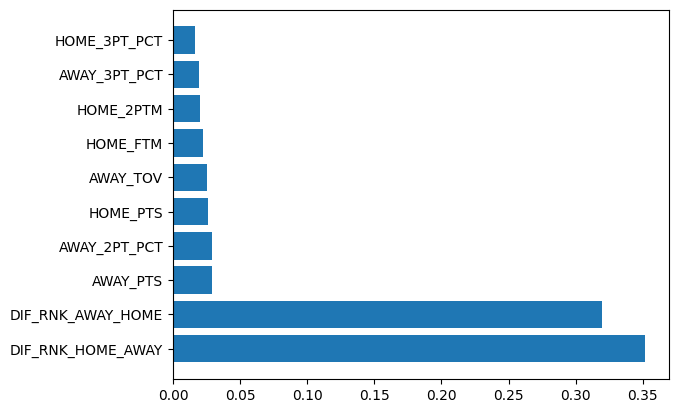

In [39]:
import numpy as np
sorted_idx = best_esti.feature_importances_.argsort()[::-1]
sorted_idx
axe=np.array(selected_features)
from matplotlib import pyplot as plt
plt.barh(axe[sorted_idx][:10], best_esti.feature_importances_[sorted_idx][:10])

## Prediccion

### En esta seccion haremos finalmente el modelo de prediccion, con la clase GameSimulator (que simboliza a los partidos), y la clase TournamentSimulator (que simboliza los torneos). Lo que calcularemos es la probabilidad de ascenso y de ganar una serie para todos los equipos 

In [40]:
#Partidos
class GameSimulator:
    
    def __init__ (self, random_state = None):
        
        self.random_state = random_state 
    #predecimos partidos
    def generate_features(self, home, away, num_games = 1):
        
        assert num_games >= 1, "al menos un juego debe jugarse"
        home_data = DATA[home]["home"]
        away_data = DATA[away]["away"]
        features = []
        for home_features in home_data:
            home_sample = self.sample_generator(home_features, size = num_games) 
            features.append(home_sample) 
            
        for away_features in away_data:
            away_sample = self.sample_generator(away_features, size = num_games) 
            features.append(away_sample)   
        features = np.array(features).T
        return features
    
    def sample_generator(self, dic, size = 1, random_state = None):
        dis_name, paras = next(iter(dic.items()))
        paras_values = tuple(paras.values())
        sample = DISTRIBUTIONS_GENERATOR[dis_name].rvs(
        *paras_values,
        size=size,
        random_state=random_state)
        return sample 
    def predict_winner(self, home, away, num_games = 1):
        features=self.generate_features(home,away,num_games)
        winning_probas = estimator_pipeline.predict_proba(features)[:,1]
        outcomes = np.random.binomial(1, winning_probas)
        return list(outcomes)# lista de perdidos/ganados
    

In [41]:
#Torneo
class TournamentSimulator(GameSimulator):
    def __init__(self, n_series_length = 5, wins_to_advance = 3, random_state = None):
        self.n_series_length = n_series_length #cantidad de juegos de playoff 
        self.wins_to_advance = wins_to_advance #cantidad de juegos a ganar como minimo para ganar la serie 
        self.team_list = None 
        self.team_rankings=['San Isidro', 'Lanus','Barrio Parque','La Union Colon','Santa Paula','Gimnasia La Plata','Viedma','Villa San Martin'] 
        self.rounds = {} # numero de rondas 
        self.series_games={}
        super().__init__(random_state)
    #Simulamos el torneo 
    def simulate_playoff(self, playoff_matchups, iterations = 1, probs = True):
        self.rounds = {} 
        self.series_games={}
        self.team_list = [i[0] for i in playoff_matchups] + [i[1] for i in playoff_matchups] 
        self.num_simulations=iterations 
        for i in range(iterations):
            champion = self.single_bracket_run(playoff_matchups)
        if probs: 
            self.advancement_probabilities = self.calculate_probs()
            self.average_games_played=self.calculate_average_games()
    def single_bracket_run(self, playoff_matchups, verbose = False, probs = False):
        if self.team_list is None: 
            self.team_list = [i[0] for i in playoff_matchups] + [i[1] for i in playoff_matchups] 
        round_number, done = 0, 0 
        while not done: 
            round_winners, playoff_matchups = self.resolve_round(playoff_matchups,round_number) 
            if round_number not in self.rounds: 
                updated_round_stats = {} 
                for team in self.team_list: 
                    updated_round_stats[team] = 0 
            else: 
                updated_round_stats=self.rounds[round_number]
            for winner in round_winners: 
                updated_round_stats[winner] += 1 
            self.rounds[round_number] = updated_round_stats 
            if verbose: 
                print('{} round played'.format(round_number)) 
            if probs: 
                self.advancement_probabilities = self.calculate_probs() 
            if type(playoff_matchups) != list: 
                done = 1 
            round_number += 1 
        return playoff_matchups
    #jugamos cada ronda 
    def resolve_round(self, playoff_matchups,round_number=0): 
        round_winners = [] 
        for group in playoff_matchups: 
            winner,games_played = self.resolve_series_games(group[0], group[1]) 
            round_winners.append(winner) 
            if round_number==0:
                series_key = f"{group[0]} vs {group[1]}"
                if series_key not in self.series_games:
                    self.series_games[series_key]=[]
                self.series_games[series_key].append(games_played)
        if len(round_winners) > 1: 
            new_playoff_matchups = self.create_new_playoffs_matchups(round_winners)
            return round_winners, new_playoff_matchups 
        else: 
            return round_winners, winner
    def create_new_playoffs_matchups(self,round_winners):
        current_matchups = [] 
        #Siempre se juega en la cancha del mejor ubicado 
        for index in range(0, len(round_winners), 2): 
            team1=round_winners[index] 
            team2=round_winners[index + 1] 
            if self.team_rankings.index(team1)<self.team_rankings.index(team2): 
                new_group = [team1,team2] 
            else: 
                new_group = [team2,team1] 
            current_matchups.append(new_group)
        return current_matchups
    #jugamos n juegos 
    def resolve_series_games(self, team1, team2): 
        #Victorias de equipo con ventaja de localia 
        wins_team1=0 
        #Victorias de equipo sin ventaja de localia 
        wins_team2=0 
        #Las series son 2-2-1, es decir primero juega 2 veces un equipo de local, luego otro y asi sucesivamente, siempre el mejor juega primero 
        series_home=[True,True,False,False,True] 
        #A partir de aqui, se toma como 1 las victorias de local de cada partido, 
        game_engine=GameSimulator() 
        for team1_is_home in series_home: 
            if team1_is_home: 
                result = game_engine.predict_winner(team1,team2,1) 
            else: 
                result = game_engine.predict_winner(team2,team1,1) 
            if result[0]==1: 
                if team1_is_home: 
                    wins_team1+=1 
                else: 
                    wins_team2+=1 
            else: 
                if team1_is_home: 
                    wins_team2+=1 
                else: 
                    wins_team1+=1 
            #Playoff termina tras 3 partidos ganados por parte de un equipo 
            if wins_team1==self.wins_to_advance or wins_team2==self.wins_to_advance: 
                break 
        if wins_team1==self.wins_to_advance: 
            winner=team1 
        else: 
            winner=team2
        games_played=wins_team1+wins_team2
        return winner,games_played
    #sacamos probabilidades 
    def calculate_probs(self): 
        round_names = {
            0: "Semifinales",
            1: "Final"
        }
        advancement_probabilities = copy.deepcopy(self.rounds) 
        named_probabilities = {}
        for round_number in advancement_probabilities:
            round_name = round_names.get(round_number, f"Ronda {round_number}")
            named_probabilities[round_name] = {}
            for team in advancement_probabilities[round_number]:
                named_probabilities[round_name][team] = advancement_probabilities[round_number][team]/self.num_simulations 
        return named_probabilities
    def calculate_average_games(self):
        average_games={}
        for series_key, games_list in self.series_games.items():
            average=sum(games_list)/len(games_list)
            average_games[series_key]=round(average)
        return average_games

### Llaves de playoffs

In [42]:

playoff_matchups = [
     ('Lanus', 'Gimnasia La Plata'),  # group A 
     ('San Isidro', 'La Union Colon'), # group B
]

### Simulacion de playoff

In [43]:
%%time

# iniciamos el playoff
playoff = TournamentSimulator()
# simulamos playoff
playoff.simulate_playoff(playoff_matchups, iterations = 5000)

CPU times: total: 37min 21s
Wall time: 5min 10s


### Probabilidades. 0=Semifinales. 1=Final (y ascenso)

In [44]:
playoff.advancement_probabilities

{'Semifinales': {'Lanus': 0.76,
  'San Isidro': 0.7962,
  'Gimnasia La Plata': 0.24,
  'La Union Colon': 0.2038},
 'Final': {'Lanus': 0.4078,
  'San Isidro': 0.4658,
  'Gimnasia La Plata': 0.06,
  'La Union Colon': 0.0664}}

### Promedio de juegos jugados

In [45]:
playoff.average_games_played

{'Lanus vs Gimnasia La Plata': 4, 'San Isidro vs La Union Colon': 5}

### Graficos

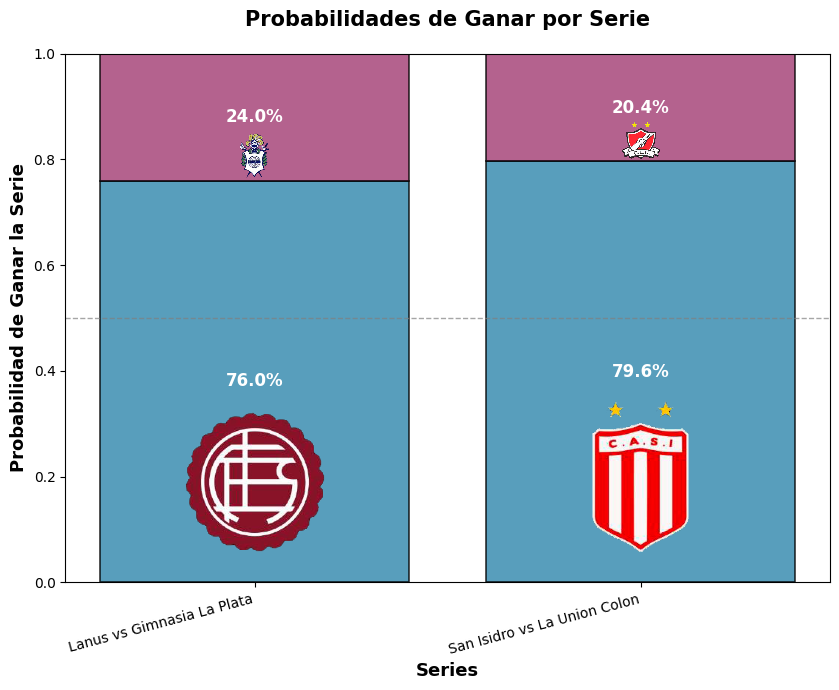

In [48]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image

# Diccionario con las rutas de los logos
team_logos = {
    'San Isidro': 'San-Isidro.png',
    'Gimnasia La Plata': 'Gimnasia-LaPlata.png',
    'La Union Colon': 'La-Union-Colon.png',
    'Lanus': 'Lanus.png',
}

playoff_series = []
for group in playoff_matchups:
    playoff_series.append(f"{group[0]} vs {group[1]}")

probability_home = []
probability_away = []
for group in playoff_matchups:
    probability_home.append(playoff.advancement_probabilities["Semifinales"][group[0]])
    probability_away.append(playoff.advancement_probabilities["Semifinales"][group[1]])

# Crear figura (más estrecha para una sola serie)
fig, ax = plt.subplots(figsize=(8.5, 7))

colors_home = '#2E86AB'
colors_away = '#A23B72'

# Crear barras
bars1 = ax.bar(playoff_series, probability_home, color=colors_home, 
               edgecolor='black', linewidth=1.2, alpha=0.8)
bars2 = ax.bar(playoff_series, probability_away, bottom=probability_home, 
               color=colors_away, edgecolor='black', linewidth=1.2, alpha=0.8)

# Añadir porcentajes
for i, (p_home, p_away) in enumerate(zip(probability_home, probability_away)):
    ax.text(i, p_home/2, f'{p_home:.1%}', ha='center', va='center',
            fontweight='bold', color='white', fontsize=12)
    ax.text(i, p_home + p_away/2, f'{p_away:.1%}', ha='center', va='center',
            fontweight='bold', color='white', fontsize=12)

# Añadir logos dentro de las barras
for i, matchup in enumerate(playoff_matchups):
    team_home, team_away = matchup
    
    # Logo equipo local (en el centro de su sección)
    if team_home in team_logos:
        img_home = Image.open(team_logos[team_home])
        imagebox_home = OffsetImage(img_home, zoom=probability_home[i]*0.7)
        ab_home = AnnotationBbox(imagebox_home, (i, probability_home[i]*0.25), 
                                  frameon=False, xycoords='data')
        ax.add_artist(ab_home)
    
    # Logo equipo visitante (en el centro de su sección)
    if team_away in team_logos:
        img_away = Image.open(team_logos[team_away])
        imagebox_away = OffsetImage(img_away, zoom=probability_away[i]*0.7)
        ab_away = AnnotationBbox(imagebox_away, (i, 1-probability_away[i]*0.80), 
                                  frameon=False, xycoords='data')
        ax.add_artist(ab_away)

# Personalización
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.set_ylabel('Probabilidad de Ganar la Serie', fontsize=13, fontweight='bold')
ax.set_xlabel('Series', fontsize=13, fontweight='bold')
ax.set_title('Probabilidades de Ganar por Serie', fontsize=15, fontweight='bold', pad=20)
ax.set_ylim(0, 1.0)
plt.xticks(rotation=15, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

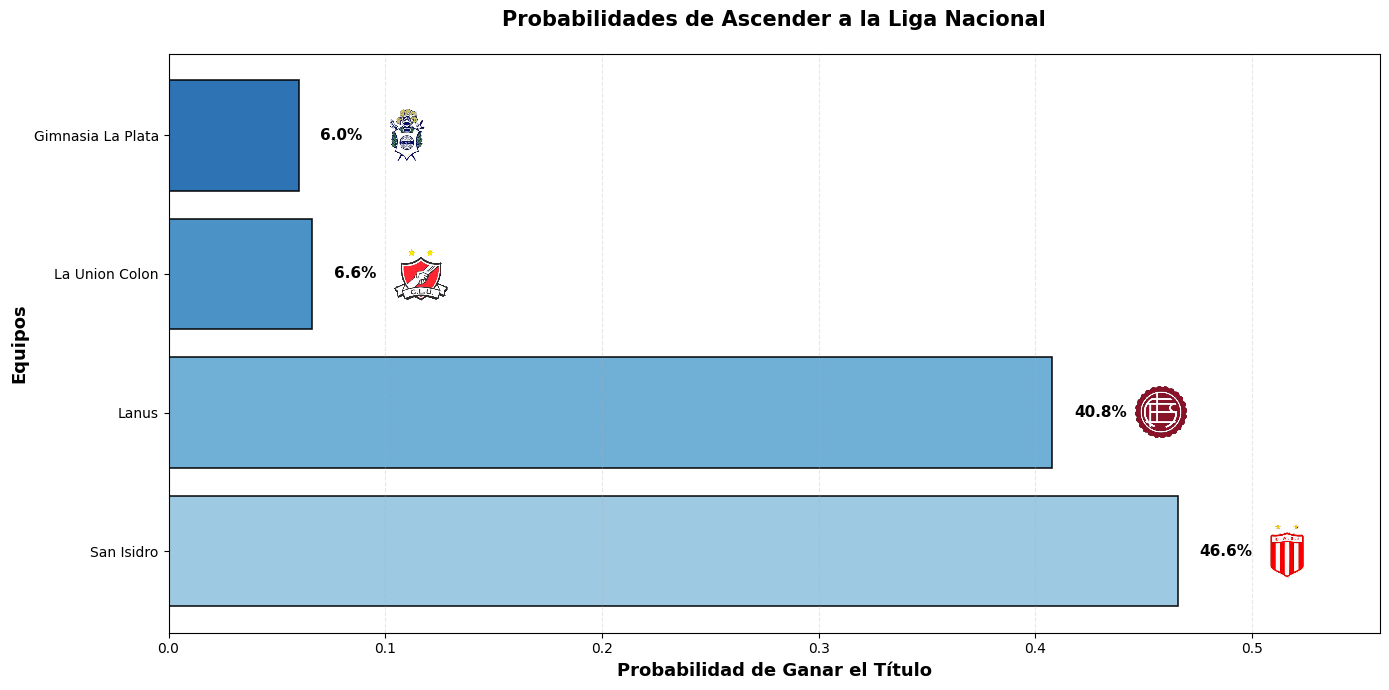

In [49]:
# Extraer probabilidades de ganar el título (ronda 1)
championship_probs = playoff.advancement_probabilities["Final"]
# Diccionario con las rutas de los logos
team_logos = {
    'San Isidro': 'San-Isidro.png',
    'Gimnasia La Plata': 'Gimnasia-LaPlata.png',
    'La Union Colon': 'La-Union-Colon.png',
    'Lanus': 'Lanus.png',
}
# Ordenar de mayor a menor
teams = list(championship_probs.keys())
probs = list(championship_probs.values())
sorted_data = sorted(zip(teams, probs), key=lambda x: x[1], reverse=True)
teams_sorted = [x[0] for x in sorted_data]
probs_sorted = [x[1] for x in sorted_data]

# Crear figura
fig, ax = plt.subplots(figsize=(14, 7))

# Crear barras horizontales
colors = plt.cm.Blues(np.linspace(0.4, 0.8, len(teams_sorted)))
bars = ax.barh(teams_sorted, probs_sorted, color=colors, 
               edgecolor='black', linewidth=1.2, alpha=0.9)

# Añadir porcentajes
for i, (team, prob) in enumerate(zip(teams_sorted, probs_sorted)):
    ax.text(prob + 0.01, i, f'{prob:.1%}', 
            va='center', fontweight='bold', fontsize=11)
    
    # Añadir logo a la derecha del porcentaje
    if team in team_logos:
        img = Image.open(team_logos[team])
        imagebox = OffsetImage(img, zoom=0.20)
        # Posición: a la derecha del texto de porcentaje
        ab = AnnotationBbox(imagebox, (prob+0.05, i), 
                           frameon=False, xycoords='data')
        ax.add_artist(ab)

# Personalización
ax.set_xlabel('Probabilidad de Ganar el Título', fontsize=13, fontweight='bold')
ax.set_ylabel('Equipos', fontsize=13, fontweight='bold')
ax.set_title('Probabilidades de Ascender a la Liga Nacional', fontsize=15, fontweight='bold', pad=20)
ax.set_xlim(0, max(probs_sorted) * 1.20)  # Más espacio para logos
ax.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()